In [2]:
!pip install tensorflow matplotlib numpy


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import ssl
import os

ssl._create_default_https_context = ssl._create_unverified_context
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['SSL_CERT_FILE'] = ''

In [4]:
train_dir = "data/Val"
val_dir = "data/Val"

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 604 images belonging to 4 classes.
Found 604 images belonging to 4 classes.


In [6]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,588 (9.26 MB)

 Trainable params: 167,044 (652.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 342ms/step - accuracy: 0.7103 - loss: 0.8441 - val_accuracy: 0.9305 - val_loss: 0.1950
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 324ms/step - accuracy: 0.9387 - loss: 0.1775 - val_accuracy: 0.9685 - val_loss: 0.0911
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.9503 - loss: 0.1503 - val_accuracy: 0.9917 - val_loss: 0.0500
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step - accuracy: 0.9685 - loss: 0.0817 - val_accuracy: 0.9967 - val_loss: 0.0314
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.9818 - loss: 0.0563 - val_accuracy: 0.9983 - val_loss: 0.0200
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 333ms/step - accuracy: 0.9818 - loss: 0.0512 - val_accuracy: 1.0000 - val_loss: 0.0153
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 335ms/step - accuracy: 0.9785 - loss: 0.0669 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 344ms/step - accuracy: 0.9818 - loss: 0.0474 - val_accuracy: 1.

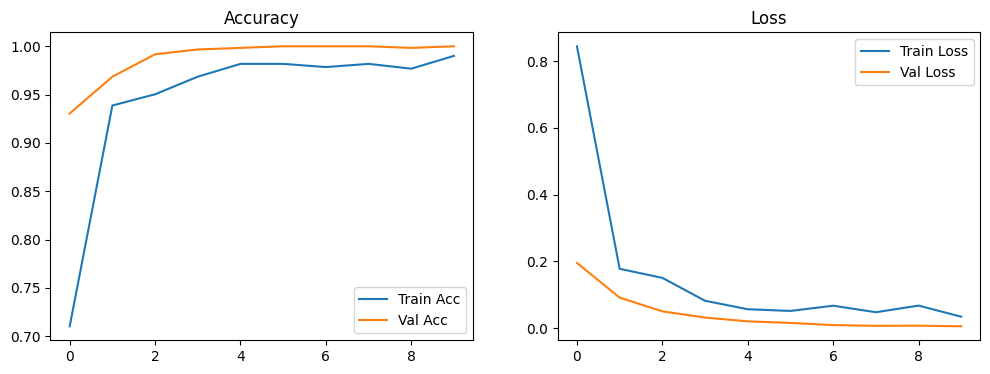

In [10]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [11]:
model.save("mobilenetv2_waste_classifier.h5")


In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [17]:
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_0_1378782.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg")
predict_image("/Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_0_1378782.jpg
Prediction: cardboard
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg
Prediction: glass
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg
Prediction: metal
Confidence: 1.00
------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Image: /Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg
Prediction: plastic
Confidence: 1.00
------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


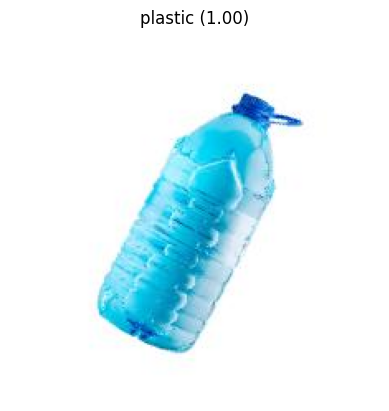

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


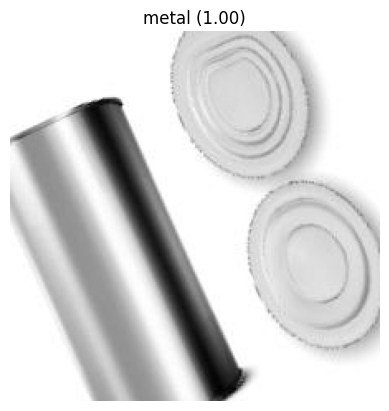

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


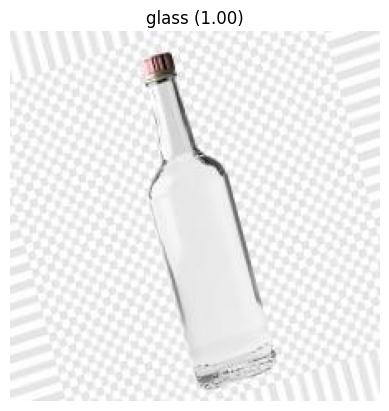

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


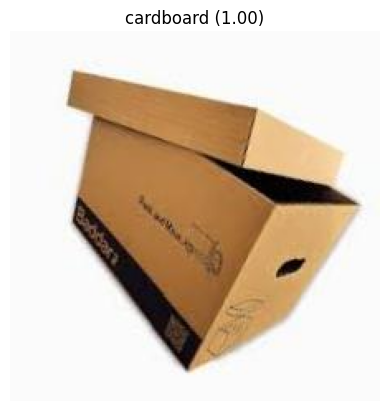

In [23]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def show_and_predict(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.title(f"{predicted_class} ({confidence:.2f})")
    plt.show()

show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/plastic/aug_0_1157492.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/metal/aug_0_935631.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/glass/aug_0_2872392.jpg")
show_and_predict("/Users/ameer/Desktop/Healix-main/data/Val/cardboard/aug_1_3274475.jpg")